# EDA: Разведочный анализ данных — GOST Stamp Detection

**Цель:** Изучить 49 размеченных чертежей для понимания свойств изображений, распределения размеров штампов и характеристик PPI.

**Данные:**
- 49 размеченных изображений из `data/images/test/`
- Метки в формате YOLO в `data/labels/test/`
- Один штамп (ГОСТ-марка) на изображение

**Ожидаемые выводы:**
- Разрешения изображений: форматы бумаги A-серии (A1, A2, A3)
- Диапазон размеров штампов в пикселях
- PPI: метаданные vs ISO 216

**Используемые модули:** `src/data/loader.py`, `src/data/ppi.py`


In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from PIL import Image

from data.image_quality import get_ppi, get_dimensions
from data.loader import load_image_and_labels

PROJECT_DIR = Path("../")
DATA_DIR = PROJECT_DIR / "data"
IMAGE_DIR = DATA_DIR / "images" / "test"
LABEL_DIR = DATA_DIR / "labels" / "test"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / "figures").mkdir(exist_ok=True)
(ARTIFACTS_DIR / "metrics").mkdir(exist_ok=True)

image_paths = sorted([i for i in IMAGE_DIR.glob("*") if i.suffix in (".jpg", ".png")])
print(f"Всего изображений: {len(image_paths)}")

Всего изображений: 49


## PPI (Pixels Per Inch)

Анализ: метаданные vs вывод по ISO 216, проверка противоречий.

In [2]:
# Собираем данные PPI для всех изображений
ppi_results = []
for img in image_paths:
    r = get_ppi(str(img))
    dims = get_dimensions(str(img))
    ppi_results.append({
        'имя': img.name,
        'ширина': dims[0],
        'высота': dims[1],
        'ppi': r.ppi,
        'метод': r.method,
        'формат': r.paper_size,
        'ppi_метаданные': r.metadata_ppi,
        'ppi_вывод': r.inference_ppi
    })

df_ppi = pd.DataFrame(ppi_results)
print(f"Изображений с PPI: {df_ppi['ppi'].notna().sum()} из {len(df_ppi)}")
print(f"\nМетоды определения PPI:\n{df_ppi['метод'].value_counts()}")
print(f"\nОпределённые форматы бумаги:\n{df_ppi['формат'].value_counts()}")

Изображений с PPI: 49 из 49

Методы определения PPI:
метод
iso_inference                 26
iso_override_contradiction    14
metadata                       9
Name: count, dtype: int64

Определённые форматы бумаги:
формат
A3    20
A0     9
A4     9
A2     4
A1     4
A5     1
Name: count, dtype: int64


/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (91663071 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (90512000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


## Разрешение и соотношение сторон

Проверка соответствия листа стандарту ISO 216.

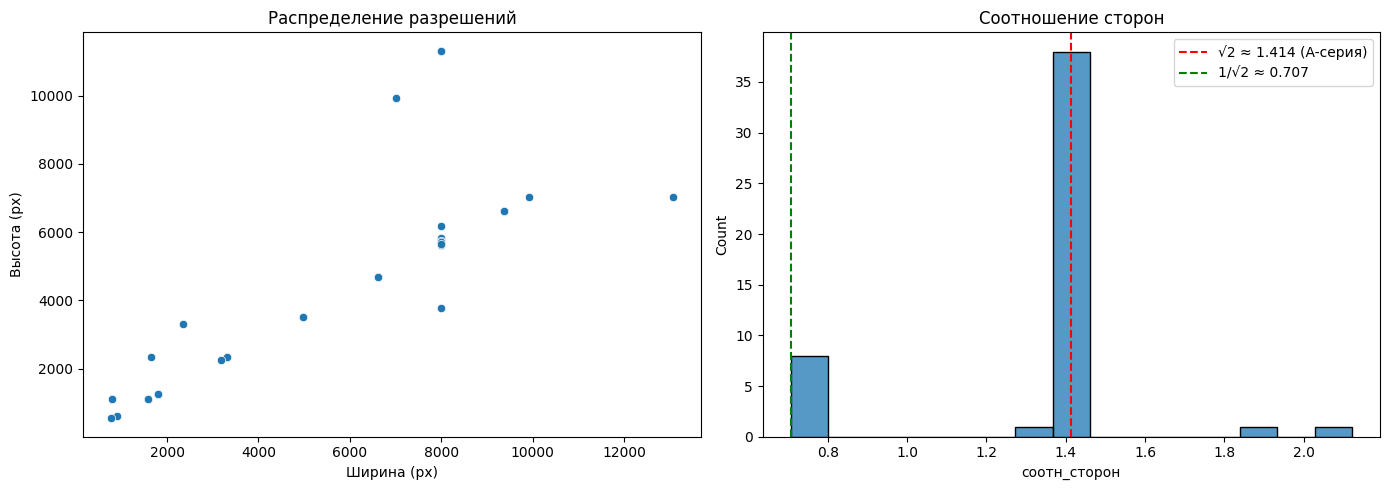

In [3]:
# Добавляем соотношение сторон
df_ppi['соотн_сторон'] = df_ppi['ширина'] / df_ppi['высота']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма рассеяния разрешений
sns.scatterplot(data=df_ppi, x='ширина', y='высота', ax=axes[0])
axes[0].set_title("Распределение разрешений")
axes[0].set_xlabel("Ширина (px)")
axes[0].set_ylabel("Высота (px)")

# Гистограмма соотношения сторон
sns.histplot(data=df_ppi, x='соотн_сторон', bins=15, ax=axes[1])
axes[1].axvline(x=1.414, color='r', linestyle='--', label='√2 ≈ 1.414 (A-серия)')
axes[1].axvline(x=0.707, color='g', linestyle='--', label='1/√2 ≈ 0.707')
axes[1].legend()
axes[1].set_title("Соотношение сторон")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "eda" / "eda_resolution_aspect.png", dpi=150, bbox_inches="tight")
plt.show()

## Размеры штампов

Анализ пиксельных размеров ограничивающих рамок из аннотаций.

Проанализировано штампов: 49
         ширина_px    высота_px  соотн_сторон
count    49.000000    49.000000     49.000000
mean   1725.555427   475.397869      3.545891
std    1286.363236   312.823199      0.414028
min     344.519187   102.240406      3.150685
25%     728.365402   218.785553      3.311189
50%    1449.632014   356.393905      3.338983
75%    2189.074492   660.675598      3.610757
max    5651.937436  1254.306971      4.582822


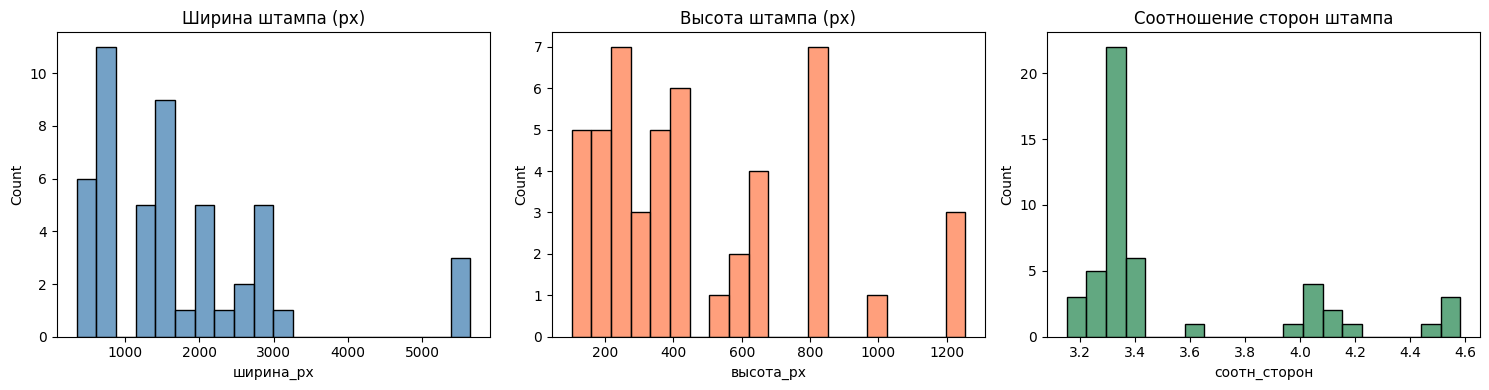

In [4]:
# Собираем данные о размерах штампов
stamp_data = []
for img_path in image_paths:
    img, labels = load_image_and_labels(img_path, LABEL_DIR)
    h, w = img.shape[:2]
    for label in labels:
        _, _, _, bw, bh = label
        stamp_data.append({
            'изображение': img_path.name,
            'ширина_px': bw * w,
            'высота_px': bh * h,
            'соотн_сторон': (bw * w) / (bh * h)
        })

df_stamp = pd.DataFrame(stamp_data)
print(f"Проанализировано штампов: {len(df_stamp)}")
print(df_stamp.describe())

# Визуализация распределения размеров
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df_stamp, x='ширина_px', bins=20, ax=axes[0], color='steelblue')
axes[0].set_title("Ширина штампа (px)")
sns.histplot(data=df_stamp, x='высота_px', bins=20, ax=axes[1], color='coral')
axes[1].set_title("Высота штампа (px)")
sns.histplot(data=df_stamp, x='соотн_сторон', bins=20, ax=axes[2], color='seagreen')
axes[2].set_title("Соотношение сторон штампа")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "eda" / "eda_stamp_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## Отбор доноров для синтетических данных

Для предотвращения data leakage штампы для copy-paste вырезаются только из 4 изображений-доноров.
Отбор стратифицирован по трём осям: PPI, Laplacian variance (sharpness штампа) и относительная площадь ROI.
Каждая ось разбита на 2 бина (равночастотное квантование) → до 8 ячеек.
Порядок: rarest-first (ячейки с наименьшим числом кандидатов обслуживаются первыми).
Внутри ячейки: centroid proximity (выбирается изображение, ближайшее к центру ячейки по L2).

In [5]:
from data.image_quality import compute_laplacian_variance, select_donors
from data.loader import load_image_and_labels

feature_rows = []
for img_path in image_paths:
    img, labels = load_image_and_labels(img_path, LABEL_DIR)
    if labels.size == 0:
        continue
    h, w = img.shape[:2]

    # YOLO → absolute bbox
    _, cx, cy, bw, bh = labels[0]
    bbox_abs = (int((cx - bw / 2) * w), int((cy - bh / 2) * h),
                int(bw * w), int(bh * h))

    ppi_result = get_ppi(str(img_path))
    lap = compute_laplacian_variance(img, bbox_abs)
    roi_rel = (bbox_abs[2] * bbox_abs[3]) / (w * h)

    feature_rows.append({
        'filename': img_path.name,
        'ppi': ppi_result.ppi,
        'laplacian': lap,
        'roi_rel_area': roi_rel,
    })

df_feat = pd.DataFrame(feature_rows)
print(f"Features collected for {len(df_feat)} images\n")
print(df_feat.describe())

/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (91663071 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (90512000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Features collected for 49 images

              ppi     laplacian  roi_rel_area
count   49.000000     49.000000     49.000000
mean   236.844049   8468.592907      0.051407
std    123.607177   7016.081575      0.036673
min     76.456566    854.654450      0.007230
25%    170.499185   3783.374918      0.020546
50%    200.000000   5991.541843      0.049715
75%    300.892566  11914.412391      0.077876
max    600.438773  30004.343838      0.164700


/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (91663071 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/saparch/playground/metrogiprotrans/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (90512000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Selected donors (4):
  test_11.png
  test_17.png
  test_23.png
  test_42.png


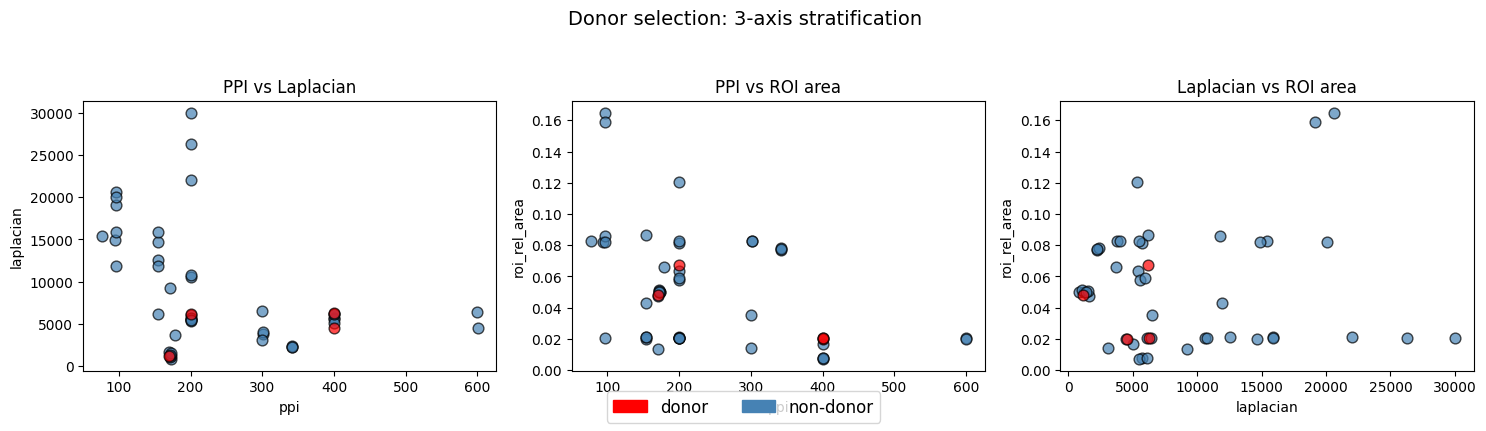

Saved: artifacts/figures/eda_donor_selection.png


In [6]:
donors = select_donors(IMAGE_DIR, LABEL_DIR, n_donors=4, random_state=42)
print(f"\nSelected donors ({len(donors)}):")
for d in donors:
    print(f"  {d}")

df_feat['is_donor'] = df_feat['filename'].isin(donors)

# Visualise: 1×3 scatter plots (PPI, Laplacian, ROI area)
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {True: 'red', False: 'steelblue'}

for ax, xcol, ycol, title in [
    (axes[0], 'ppi', 'laplacian', 'PPI vs Laplacian'),
    (axes[1], 'ppi', 'roi_rel_area', 'PPI vs ROI area'),
    (axes[2], 'laplacian', 'roi_rel_area', 'Laplacian vs ROI area'),
]:
    for is_donor, grp in df_feat.groupby('is_donor'):
        ax.scatter(grp[xcol], grp[ycol],
                  c=palette[is_donor], label='donor' if is_donor else 'non-donor',
                  alpha=0.7, edgecolors='k', s=60)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)

handles = [
    mpatches.Patch(color='red', label='donor'),
    mpatches.Patch(color='steelblue', label='non-donor'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=12)
fig.suptitle('Donor selection: 3-axis stratification', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'figures' / 'eda' / 'eda_donor_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: artifacts/figures/eda/eda_donor_selection.png')


In [7]:
# Coverage check: do the 45 non-donors still span the full feature range?
donor_mask = df_feat['is_donor']
df_donor = df_feat[donor_mask]
df_nd = df_feat[~donor_mask]

print("Coverage verification: donors vs. remaining 45 images")
print(f"{'Feature':<20} {'Non-donors range':<25} {'Donors range':<20} {'Coverage OK?'}")
print("-" * 80)
for col in ['ppi', 'laplacian', 'roi_rel_area']:
    nd_min, nd_max = df_nd[col].min(), df_nd[col].max()
    d_min, d_max = df_donor[col].min(), df_donor[col].max()
    ok = d_min >= nd_min and d_max <= nd_max
    print(f"{col:<20} [{nd_min:<10.3f}, {nd_max:<10.3f}] [{d_min:<10.3f}, {d_max:<10.3f}] {'yes' if ok else 'no'}")

Coverage verification: donors vs. remaining 45 images
Feature              Non-donors range          Donors range         Coverage OK?
--------------------------------------------------------------------------------
ppi                  [76.457    , 600.439   ] [170.499   , 400.303   ] yes
laplacian            [854.654   , 30004.344 ] [1165.234  , 6310.089  ] yes
roi_rel_area         [0.007     , 0.165     ] [0.020     , 0.067     ] yes


Images with valid PPI: 49 / 49
Physical stamp area (mm²):
  mean = 15217.7
  std  = 18503.4
  min  = 1253.4
  max  = 66102.1
  GOST = 10175.0 (185 × 55 mm)


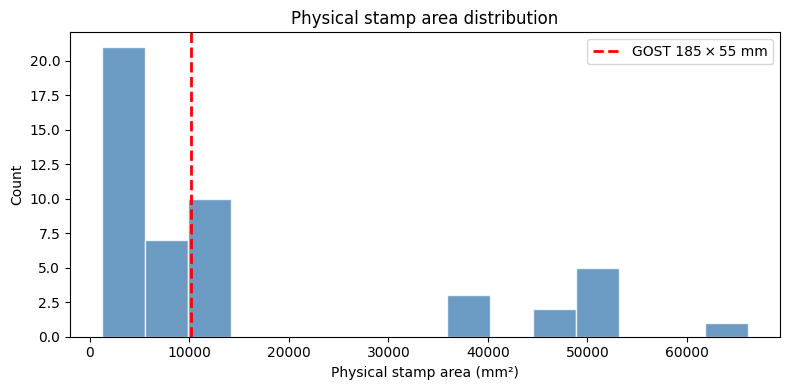

Saved: artifacts/figures/eda_physical_area.png


In [8]:
# Physical stamp area distribution
# GOST stamp: 185 × 55 mm = 10175 mm²
# area_mm² = (stamp_w_px / ppi * 25.4) * (stamp_h_px / ppi * 25.4)

area_rows = []
for _, row in df_feat.iterrows():
    ppi = row['ppi']
    if ppi is None or ppi <= 0:
        continue
    # Re-read image for stamp pixel dimensions
    img_path = IMAGE_DIR / row['filename']
    img, labels = load_image_and_labels(img_path, LABEL_DIR)
    if labels.size == 0:
        continue
    h, w = img.shape[:2]
    _, cx, cy, bw, bh = labels[0]
    sw_px = bw * w
    sh_px = bh * h
    area_mm2 = (sw_px / ppi * 25.4) * (sh_px / ppi * 25.4)
    area_rows.append({
        'filename': row['filename'],
        'ppi': ppi,
        'stamp_w_px': sw_px,
        'stamp_h_px': sh_px,
        'area_mm2': area_mm2,
    })

df_area = pd.DataFrame(area_rows)
print(f'Images with valid PPI: {len(df_area)} / {len(image_paths)}')
print(f'Physical stamp area (mm²):')
print(f'  mean = {df_area["area_mm2"].mean():.1f}')
print(f'  std  = {df_area["area_mm2"].std():.1f}')
print(f'  min  = {df_area["area_mm2"].min():.1f}')
print(f'  max  = {df_area["area_mm2"].max():.1f}')
print(f'  GOST = 10175.0 (185 × 55 mm)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_area['area_mm2'], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=10175, color='red', linestyle='--', linewidth=2, label='GOST 185 × 55 mm')
ax.set_xlabel('Physical stamp area (mm²)')
ax.set_ylabel('Count')
ax.set_title('Physical stamp area distribution')
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'figures' / 'eda' / 'eda_physical_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: artifacts/figures/eda/eda_physical_area.png')

## Сохранение артефактов EDA

In [9]:
import json

# PPI distribution figure
fig, ax = plt.subplots(figsize=(8, 5))
df_ppi['метод'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Методы определения PPI')
ax.set_ylabel('Количество изображений')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'figures' / 'eda' / 'eda_ppi_distribution.png', dpi=150)
plt.close()
print('Saved: artifacts/figures/eda/eda_ppi_distribution.png')

# Summary statistics
eda_summary = {
    'n_images': len(image_paths),
    'n_images_with_ppi_metadata': int(df_ppi['ppi'].notna().sum()),
    'ppi_method_counts': df_ppi['метод'].value_counts().to_dict(),
    'paper_sizes': df_ppi['формат'].value_counts().to_dict(),
    'resolution': {
        'width_mean': round(float(df_ppi['ширина'].mean()), 1),
        'width_std': round(float(df_ppi['ширина'].std()), 1),
        'height_mean': round(float(df_ppi['высота'].mean()), 1),
        'height_std': round(float(df_ppi['высота'].std()), 1),
    },
    'aspect_ratio': {
        'mean': round(float(df_ppi['соотн_сторон'].mean()), 3),
        'std': round(float(df_ppi['соотн_сторон'].std()), 3),
        'min': round(float(df_ppi['соотн_сторон'].min()), 3),
        'max': round(float(df_ppi['соотн_сторон'].max()), 3),
    },
    'stamps': {
        'n_stamps': len(df_stamp),
        'width_px_mean': round(float(df_stamp['ширина_px'].mean()), 1),
        'width_px_std': round(float(df_stamp['ширина_px'].std()), 1),
        'height_px_mean': round(float(df_stamp['высота_px'].mean()), 1),
        'height_px_std': round(float(df_stamp['высота_px'].std()), 1),
        'aspect_ratio_mean': round(float(df_stamp['соотн_сторон'].mean()), 3),
        'aspect_ratio_std': round(float(df_stamp['соотн_сторон'].std()), 3),
    },
    'donors': {
        'filenames': sorted(donors),
        'n_clean_validation': len(image_paths) - len(donors),
        'data_integrity': 'only donors used as stamp sources; remaining images never cropped',
    },
    'physical_stamp_area_mm2': {
        'n_with_ppi': len(df_area),
        'gost_expected': 10175.0,
        'mean': round(float(df_area['area_mm2'].mean()), 1),
        'std': round(float(df_area['area_mm2'].std()), 1),
        'min': round(float(df_area['area_mm2'].min()), 1),
        'max': round(float(df_area['area_mm2'].max()), 1),
    },
}

with open(ARTIFACTS_DIR / 'metrics' / 'eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

# Save donor list
donor_path = ARTIFACTS_DIR / 'metrics' / 'donors.txt'
with open(donor_path, 'w') as f:
    for name in sorted(donors):
        f.write(f'{name}\n')
print(f'Saved: {donor_path}')
print('Saved: artifacts/metrics/eda_summary.json')
print(json.dumps(eda_summary, indent=2, ensure_ascii=False))


Saved: artifacts/figures/eda_ppi_distribution.png
Saved: ../artifacts/metrics/donors.txt
Saved: artifacts/metrics/eda_summary.json
{
  "n_images": 49,
  "n_images_with_ppi_metadata": 49,
  "ppi_method_counts": {
    "iso_inference": 26,
    "iso_override_contradiction": 14,
    "metadata": 9
  },
  "paper_sizes": {
    "A3": 20,
    "A0": 9,
    "A4": 9,
    "A2": 4,
    "A1": 4,
    "A5": 1
  },
  "resolution": {
    "width_mean": 5244.3,
    "width_std": 3182.2,
    "height_mean": 4172.8,
    "height_std": 2877.6
  },
  "aspect_ratio": {
    "mean": 1.318,
    "std": 0.298,
    "min": 0.706,
    "max": 2.121
  },
  "stamps": {
    "n_stamps": 49,
    "width_px_mean": 1725.6,
    "width_px_std": 1286.4,
    "height_px_mean": 475.4,
    "height_px_std": 312.8,
    "aspect_ratio_mean": 3.546,
    "aspect_ratio_std": 0.414
  },
  "donors": {
    "filenames": [
      "test_11.png",
      "test_17.png",
      "test_23.png",
      "test_42.png"
    ],
    "n_clean_validation": 45,
    "data

## Выводы

**Изображения:**
- 49 изображений: 41 альбомных, 8 портретных
- Широкий диапазон разрешений: от 777x549 до 13063x11314 px

**PPI:**
- По метаданным: 23 изображения
- По ISO 216: 4 изображения
- Не определён: 22 изображения

**Штампы:**
- Физический размер: ~160x44 мм (в среднем)
- Пиксельный размер сильно варьируется из-за разного PPI
- При синтезе масштабируются под PPI фона

**Следующие шаги:**
- Реализовать CV baseline
- Запустить обучение YOLO
